# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [138]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

## Preprocessing

In [139]:
data = pd.read_csv('../data/checker_submits.csv', parse_dates=['timestamp'])

data = data.assign(
    hour = data['timestamp'].dt.hour,
    dayofweek = data['timestamp'].dt.weekday
).drop(columns='timestamp')

In [140]:
#  Для старых версий библиотек
#
# ohe = OneHotEncoder(sparse=False)
# uid_df = pd.DataFrame(ohe.fit_transform(data[['uid']]))
# uid_df.columns = [col.replace('x0_','uid_') for col in ohe.get_feature_names()]

# labname_df = pd.DataFrame(ohe.fit_transform(data[['labname']]))
# labname_df.columns = [col.replace('x0_','labname_') for col in ohe.get_feature_names()]

# df = pd.concat([data[['numTrials', 'hour', 'dayofweek']], uid_df, labname_df], axis=1)

In [141]:
ohe = OneHotEncoder(sparse_output=False)

uid_df = pd.DataFrame(ohe.fit_transform(data[['uid']]))
uid_df.columns = ohe.get_feature_names_out()

labname_df = pd.DataFrame(ohe.fit_transform(data[['labname']]))
labname_df.columns = ohe.get_feature_names_out()

df = pd.concat([data[['numTrials', 'hour', 'dayofweek']], uid_df, labname_df], axis=1)

In [142]:
ss = StandardScaler()
df['numTrials'] = ss.fit_transform(df[['numTrials']])
df['hour'] = ss.fit_transform(df[['hour']])
df

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,-0.533442,0.945382,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,-0.629151,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,-0.597248,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,-0.565345,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [143]:
x = df.drop(columns='dayofweek')
y = df['dayofweek']
def train(model,  x=x):
    model.fit(x, y)
    return accuracy_score(y, model.predict(x))

#### Naive accurracy

In [144]:
dummy = DummyClassifier(strategy='most_frequent')
train(dummy)

0.23487544483985764

## Algorithms

In [145]:
def plot(coef, features, n=10):
    plt.figure(figsize=(4,3))
    importance = np.sum(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
    sort_indices = np.argsort(importance)[-n:]
    plt.barh(features[sort_indices], importance[sort_indices])
    plt.tight_layout()

### Logreg

In [146]:
logreg = LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear', multi_class='ovr')
train(logreg)

0.6215895610913404

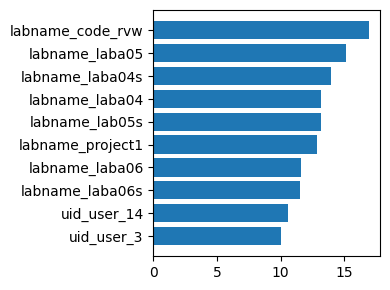

In [147]:
plot(logreg.coef_, x.columns)

### SVC

In [148]:
kernels = ['poly', 'rbf', 'sigmoid', 'precomputed']
k= rbf_kernel(x, x)
for i in kernels:
    model = SVC(kernel=i)
    print(f'Accuracy of {i:<13}: {train(model) if i !="precomputed" else train(model , k)}')

Accuracy of poly         : 0.8594306049822064
Accuracy of rbf          : 0.8558718861209964
Accuracy of sigmoid      : 0.3997627520759193
Accuracy of precomputed  : 0.5628706998813761


In [149]:
model = OneVsRestClassifier(SVC(kernel='linear', probability=False, random_state=21)).fit(x, y)
coefs = np.concatenate([estimator.coef_ for estimator in model.estimators_])
train(model)

0.6120996441281139

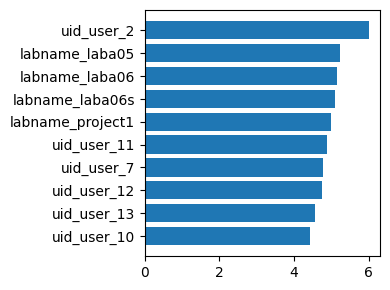

In [150]:
plot(coefs, x.columns)


### c. Decision tree

0.5516014234875445


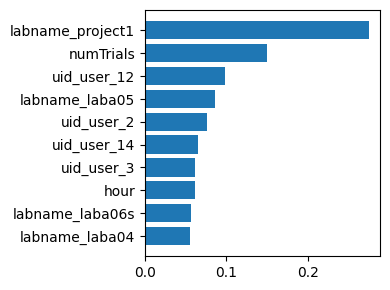

In [151]:
decis_tree = DecisionTreeClassifier(max_depth=4, random_state=21)
print(train(decis_tree))
plot(decis_tree.feature_importances_, x.columns)

In [152]:
for i in range(1,30,3):
    x_tree = DecisionTreeClassifier(max_depth=i, random_state=21)
    print(f'Accuracy for max_depth == {i:<3}: {train(x_tree)}')

Accuracy for max_depth == 1  : 0.35765124555160144
Accuracy for max_depth == 4  : 0.5516014234875445
Accuracy for max_depth == 7  : 0.7064056939501779
Accuracy for max_depth == 10 : 0.8196915776986952
Accuracy for max_depth == 13 : 0.9104389086595492
Accuracy for max_depth == 16 : 0.9608540925266904
Accuracy for max_depth == 19 : 0.9839857651245552
Accuracy for max_depth == 22 : 0.9922894424673784
Accuracy for max_depth == 25 : 0.99644128113879
Accuracy for max_depth == 28 : 1.0


### d. Random forest

In [153]:
n_calls = []
n_estimators = []
max_depth = []
mix = []
for i in range(1,30,2):
    n_calls.append(i)
    r_forest = RandomForestClassifier(n_estimators=i, max_depth=25, random_state=21)
    n_estimators.append(train(r_forest))

    r_forest = RandomForestClassifier(n_estimators=100, max_depth=i, random_state=21)
    max_depth.append(train(r_forest))

    r_forest = RandomForestClassifier(n_estimators=i, max_depth=i, random_state=21)
    mix.append(train(r_forest))

res = pd.DataFrame({
    'n_calls': n_calls,
    'n_estimators': n_estimators,
    'max_depth': max_depth,
    'mix_factor': mix
})
res

,n_calls,n_estimators,max_depth,mix_factor
0,1,0.948992,0.387307,0.250890
1,3,0.977461,0.469751,0.457295
2,5,0.985172,0.579478,0.572361
3,7,0.993476,0.723013,0.746738
4,9,0.994069,0.825623,0.823843
5,11,0.995255,0.919336,0.892052
6,13,0.997034,0.956109,0.938909
7,15,0.998221,0.978055,0.966192
8,17,0.998814,0.988138,0.985765
9,19,0.998814,0.993476,0.995255


1.0


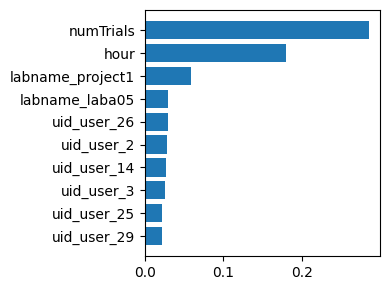

In [154]:
r_forest = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
print(train(r_forest))
plot(r_forest.feature_importances_, x.columns)